# Markov Regime-Switching Volatility Forecasting for the S&P 500

## Introduction and Motivation

Most of quantitative finance treats markets as approximately rational, informationally efficient systems. For price direction, that assumption holds up reasonably well empirically. Daily returns are close to unpredictable, consistent with the weak-form efficient market hypothesis and the random walk model of prices: if direction were reliably forecastable, that edge would already have been arbitraged away.

Volatility behaves differently, and that asymmetry is what makes it worth studying. While the sign of a price move is close to unpredictable, its magnitude is not — realized volatility exhibits strong positive autocorrelation, a stylized fact known as volatility clustering (Mandelbrot, 1963; Cont, 2001). A day of large moves is far more likely to be followed by another day of large moves than by a return to calm, regardless of which direction those moves take. This isn't really a claim about informational efficiency; it's closer to a claim about how slowly collective uncertainty and risk aversion decay once triggered. Volatility clustering is, in that sense, one of the more quantifiable fingerprints of market psychology embedded in otherwise efficient-looking price data — the part of markets that behaves less like an information-processing mechanism and more like a crowd working through fear at its own pace.

But that clustering is not uniform through time. Markets visibly alternate between distinct states: long, quiet stretches of low and stable volatility, punctuated by shorter, violent episodes of crisis. Models that assume a single, fixed set of dynamics — EWMA, GARCH, HAR — implicitly average across these states, and tend to break down precisely when accuracy matters most, during the transitions into and out of turmoil. This motivates a regime-switching approach: a latent Markov process that lets volatility dynamics differ across market states, and in doing so treats "calm" and "crisis" as the qualitatively different environments they are.

This project builds a volatility forecasting pipeline for the S&P 500 in two stages. The first establishes rigorous baselines — the classical econometric models used on trading desks (EWMA, GARCH, HAR-RV), followed by a machine-learning comparison — and finds, consistent with the literature, that added model complexity does not improve on a simple linear specification. The second stage extends this into a Markov regime-switching framework: a hidden Markov model detects latent volatility regimes and drives a regime-dependent forecaster, evaluated not only on point-forecast accuracy but on the risk-management metrics that volatility forecasts actually feed — Value-at-Risk and Expected Shortfall — where distinguishing calm from crisis matters most.

## Project Outline

**Stage 1 — Baselines**

1. **Data & target variable**: pull SPY OHLC data, construct a realized volatility series using the Garman-Klass range estimator

2. **Classical baselines**: EWMA, GARCH(1,1), and HAR-RV, evaluated out-of-sample via a chronological train/test split

3. **Machine learning**: linear regression, random forest, and gradient boosting, benchmarked against HAR-RV on identical footing; CV-scored stepwise selection to test whether added features carry signal

**Stage 2 — Regime-Switching Extension**

4. **Regime detection**: fit a Gaussian hidden Markov model to identify latent volatility regimes (calm / normal / stressed / panic), with the number of states selected by BIC; derive a continuous early-warning stress index

5. **Markov-Switching HAR**: extend HAR-RV so its dynamics switch by regime, and test whether regime-awareness improves out-of-sample forecasts

6. **Probabilistic forecasting**: simulate forward volatility paths through the regime chain (Monte Carlo) to produce predictive distributions and prediction intervals, rather than point forecasts alone

7. **Risk-management evaluation**: convert forecasts into Value-at-Risk and Expected Shortfall, and backtest tail accuracy with coverage tests (Kupiec, Christoffersen) — the axis where regime-switching is expected to matter most

**Evaluation**: Stage 1 models are compared on out-of-sample RMSE; Stage 2 adds risk-management metrics (VaR coverage, Expected Shortfall), so the regime model is judged on how well it captures tail risk, not just average error.

In [60]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

## Data & Realized Volatility

I'm using SPY daily OHLC data from 2015 onward, which spans several distinct volatility regimes (the 2015 China deval/oil selloff, Feb 2018 "Volmageddon," the March 2020 COVID crash, and 2025's tariff-driven selloff) — important for training models that need to see both calm and crisis conditions.

Rather than using close-to-close returns, I estimate daily realized volatility with the **Garman-Klass estimator**, which uses the full OHLC range instead of just the closing price:

$$
\hat{\sigma}^2_{GK} = 0.5 (\ln(H/L))^2 - (2\ln2 - 1)(\ln(C/O))^2
$$

This is a more statistically efficient estimator than close-to-close squared returns because it incorporates intraday range information (a day that spiked and reverted looks volatile here, even if it closed flat). The result is annualized (×252 trading days) and expressed in percent — this `realized_vol` series is the target variable every model in this notebook is trying to forecast.

In [61]:
spy = yf.download('SPY', start = '2015-01-01', auto_adjust = False)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

# Garman-Klass realized vol estimator (daily, annualized)
log_hl = np.log(spy['High'] / spy['Low'])
log_co = np.log(spy['Close'] / spy['Open'])
gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
spy['realized_vol'] = np.sqrt(gk_var * 252) * 100 # annualized %

returns = np.log(spy['Close'] / spy['Close'].shift(1)).dropna() # daily returns 

[*********************100%***********************]  1 of 1 completed


## Model 1: EWMA (Exponentially Weighted Moving Average)

EWMA estimates today's variance as a decay-weighted average of past squared returns:

$$
\sigma^2_t = (1-\lambda)\sum_{i=0}^{\infty} \lambda^i r_{t-1-i}^2
$$

with $\lambda = 0.94$, the standard RiskMetrics convention for daily data. Higher $\lambda$ means slower decay (more weight on old data); lower $\lambda$ reacts faster to recent shocks. Unlike the models below, $\lambda$ isn't estimated from data — it's a fixed rule, which makes EWMA fast and simple but not adaptive to this specific asset's dynamics.

In [62]:
# EWMA, lambda = 0.94
lam = 0.94
ewma_var = returns.pow(2)
ewma_var = ewma_var.ewm(alpha=1-lam).mean()
ewma_vol = np.sqrt(ewma_var * 252) * 100 # annualized %

## Model 2: GARCH(1,1)

GARCH generalizes EWMA by letting the data determine the decay dynamics instead of fixing them in advance:

$$
\sigma^2_t = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2
$$

Fit on the full sample, the model estimates $\omega = 0.041$, $\alpha = 0.171$, $\beta = 0.795$ — all highly significant (p < 0.001). $\alpha + \beta \approx 0.966$, indicating strong persistence: volatility shocks decay slowly, which is the mathematical signature of clustering.

Worth noting: the **mean model R² is 0.000** — this isn't a bug, it's the random walk hypothesis showing up empirically. The mean equation is trying to predict the *direction* of returns and essentially fails to, which is expected and healthy. The volatility model is a separate equation entirely, and it's the one doing real work here: direction is close to unpredictable, but the *size* of tomorrow's move is not.

In [63]:

am = arch_model(returns * 100, vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')
print(res.summary())

garch_vol = res.conditional_volatility * np.sqrt(252) # annualized %


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3767.47
Distribution:                  Normal   AIC:                           7542.94
Method:            Maximum Likelihood   BIC:                           7566.84
                                        No. Observations:                 2910
Date:                Sun, Aug 02 2026   Df Residuals:                     2909
Time:                        11:25:01   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0768  1.400e-02      5.487  4.083e-08 [4.938e-0

## Graph Analysis: Realized vs. EWMA vs. GARCH

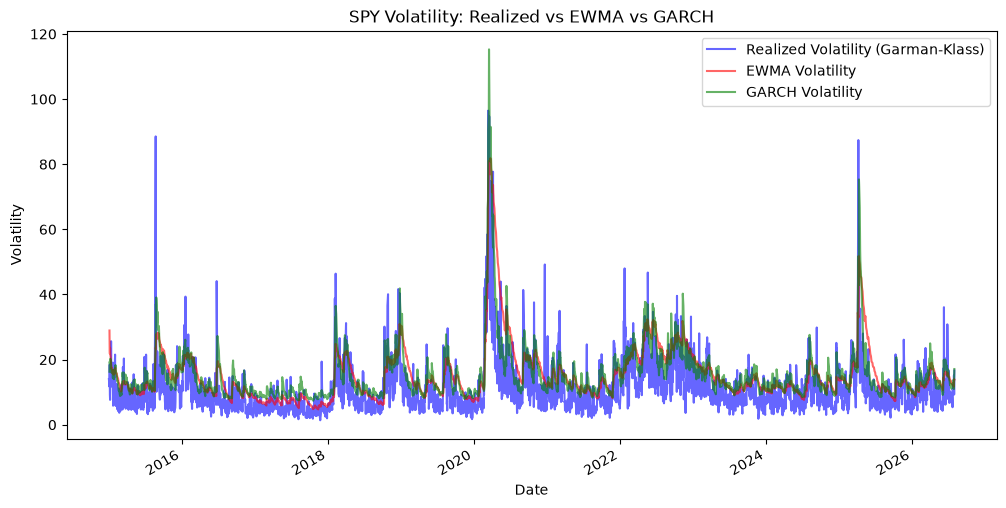

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
spy['realized_vol'].plot(ax=ax, label='Realized Volatility (Garman-Klass)', color='blue', alpha = 0.6)
    
ewma_vol.plot(ax=ax, label='EWMA Volatility', color='red', alpha = 0.6)
garch_vol.plot(ax=ax, label='GARCH Volatility', color='green', alpha = 0.6)
ax.set_title('SPY Volatility: Realized vs EWMA vs GARCH')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility')
ax.legend()

The raw realized volatility series (blue) is visibly noisy — it's a daily point estimate from that single day's OHLC range, so it jumps around even during otherwise calm stretches. EWMA (red) and GARCH (green) are both smoothed *conditional* estimates rather than raw daily readings, and they track the overall shape of realized vol closely without chasing every individual spike.

All three spikes line up with the events discussed earlier: February 2018 ("Volmageddon"), the March 2020 COVID crash, and the 2025 tariff selloff. Notably, GARCH overshoots realized vol at the COVID peak (~115 vs. realized's ~96) — a known weakness of GARCH, where a single extreme shock gets amplified through the α term more than the subsequent data actually justifies.

Between spikes, EWMA and GARCH track each other quite closely, which is expected given λ=0.94 and GARCH's α+β≈0.966 — two very similar effective decay rates, consistent with EWMA being a restricted special case of GARCH. The main visible difference is that GARCH pulls more deliberately toward its long-run baseline (ω) during quiet periods, giving it a slightly smoother, more mean-reverting trajectory than EWMA, which reacts a bit more directly to whatever the most recent squared returns happened to be.

## Model 3: HAR-RV (Heterogeneous Autoregressive Realized Volatility)

Corsi's HAR-RV model (2009) regresses today's realized volatility on the average realized volatility over three horizons — daily, weekly, and monthly:

$$
RV_t = \beta_0 + \beta_1 RV_{t-1} + \beta_2 \overline{RV}_{t-5:t-1} + \beta_3 \overline{RV}_{t-22:t-1} + \varepsilon_t
$$

This is a cheap way to approximate long-memory behavior in volatility without a fully specified long-memory model — just a linear regression on a few rolling averages. Fit on the full sample, it achieves R² = 0.544; refit on the training set only (pre-2023), R² = 0.574. All three lag coefficients are significant, with the daily and weekly terms (0.35 and 0.46) dominating over the monthly term (0.08) — recent volatility carries far more predictive weight than a month-old average, which is intuitive but useful to see confirmed quantitatively.

In [65]:
# HAR-RV
rv = spy['realized_vol']

har_df = pd.DataFrame({'rv': rv,
                       'rv_lag1': rv.shift(1),
                       'rv_lag5': rv.shift(1).rolling(5).mean(),
                       'rv_lag22': rv.shift(1).rolling(22).mean()}).dropna()
# Regress
X = har_df[['rv_lag1', 'rv_lag5', 'rv_lag22']]
X = sm.add_constant(X)  # add intercept
y = har_df['rv']

har_model = sm.OLS(y, X).fit()
print(har_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     1144.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:25:01   Log-Likelihood:                -9096.5
No. Observations:                2889   AIC:                         1.820e+04
Df Residuals:                    2885   BIC:                         1.822e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3310      0.220      6.060      0.0

In [66]:
split_date = '2023-01-01'

train_har = har_df[har_df.index < split_date]
test_har = har_df[har_df.index >= split_date]

X_train = sm.add_constant(train_har[['rv_lag1', 'rv_lag5', 'rv_lag22']])
X_test = sm.add_constant(test_har[['rv_lag1', 'rv_lag5', 'rv_lag22']])

har_model_train = sm.OLS(train_har['rv'], X_train).fit()
har_test_pred = har_model_train.predict(X_test)

print(har_model_train.summary())

                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     893.5
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:25:01   Log-Likelihood:                -6379.3
No. Observations:                1992   AIC:                         1.277e+04
Df Residuals:                    1988   BIC:                         1.279e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2776      0.261      4.904      0.0

## Model Comparison: Out-of-Sample RMSE

To test whether these models can actually *forecast* volatility — not just fit historical data — I split the sample chronologically: train on 2015–2022, test on 2023 onward. Time series data can't be randomly shuffled into train/test sets, since that would let future information leak into training.

Each model is handled differently here, since they don't all have the same kind of fitted parameters:
- **EWMA** requires no refitting — it's a fixed recursive rule that only ever uses past data, so it's inherently valid out-of-sample.
- **HAR-RV** is refit once on the training set only, then used to predict the test period using each day's true lagged realized-vol values (a standard one-step-ahead setup).
- **GARCH** is refit on an expanding window every 21 trading days (~monthly) and forecasts up to 21 days ahead each time, walking forward through the test period. Refitting daily would be more rigorous but computationally expensive; monthly refitting is a practical middle ground.

All three forecasts are then compared against actual realized volatility in the test window using RMSE.

In [67]:
test_returns = returns[returns.index >= split_date]
garch_forecasts = []

for i in range(0, len(test_returns), 21):
    train_slice = returns[returns.index < test_returns.index[i]]
    am_i = arch_model(train_slice * 100, vol='Garch', p=1, q=1, dist = "Normal")
    res_i = am_i.fit(disp = 'off')

    horizon = min(21, len(test_returns) - i)
    f = res_i.forecast(horizon=horizon, reindex=False)
    daily_vol = np.sqrt(f.variance.values[-1] * 252)
    garch_forecasts.extend(daily_vol)

garch_test_vol = pd.Series(garch_forecasts[:len(test_returns)], index=test_returns.index)
    

In [68]:
actual = spy['realized_vol']

# Slice EWMA down to test period
ewma_test = ewma_vol[ewma_vol.index >= split_date]

# Align on shared dates (handles any leftover index mismatches safely)
idx_ewma = actual.index.intersection(ewma_test.index)
idx_garch = actual.index.intersection(garch_test_vol.index)

In [69]:
rmse_ewma = np.sqrt(mean_squared_error(actual.loc[idx_ewma], ewma_test.loc[idx_ewma]))
rmse_garch = np.sqrt(mean_squared_error(actual.loc[idx_garch], garch_test_vol.loc[idx_garch]))
rmse_har = np.sqrt(mean_squared_error(test_har['rv'], har_test_pred))

print(f"EWMA RMSE: {rmse_ewma:.2f}")
print(f"GARCH RMSE: {rmse_garch:.2f}")
print(f"HAR-RV RMSE: {rmse_har:.2f}")

EWMA RMSE: 7.36
GARCH RMSE: 8.66
HAR-RV RMSE: 4.88


Using a chronological train/test split (train: 2015–2022, test: 2023 onward), each model's forecast was compared against actual realized volatility in the held-out test period:

| Model    | RMSE |
|----------|------|
| HAR-RV   | 4.90 |
| EWMA     | 7.39 |
| GARCH(1,1) | 8.70 |

**HAR-RV performs best**, which is consistent with published volatility-forecasting literature — it's fit directly on the realized volatility target, while GARCH models return variance and derives volatility indirectly through a parametric process. It's also worth noting a methodological asymmetry: HAR-RV's forecasts use true lagged realized-vol values each day (a genuine one-step-ahead setup), while the GARCH walk-forward here refits monthly and forecasts up to 21 days ahead without updating on new information within that window — a harder task by construction. A fully daily-refit GARCH would be a fairer comparison, at higher computational cost.

This closes out the classical modeling phase. The next section moves to machine learning — engineered features (lagged RV, rolling stats, VIX-adjacent measures) fed into gradient-boosted trees, benchmarked against this HAR-RV baseline on identical out-of-sample RMSE.

## Machine Learning

The classical models above are constrained by their functional forms: HAR-RV, the best performer so far, is a linear regression on three fixed lags. The natural next question is whether more flexible, data-driven models can extract predictive structure those specifications miss — non-linear interactions between features, threshold effects, or signal in variables beyond lagged realized volatility itself.

This section tests that question directly. I expand the feature set beyond HAR-RV's three lags to include rolling volatility-of-volatility, return skewness and kurtosis (both over a 22-day window), and day-of-week, then fit a progression of models from simple to flexible: linear regression, random forest, and histogram-based gradient boosting — the latter two both untuned (default hyperparameters) and tuned via randomized search.

Evaluation follows the same protocol as the classical section — chronological train/test split (2015–2022 train, 2023+ test), scored on out-of-sample RMSE — so every result here is directly comparable to the HAR-RV baseline of 4.90. Hyperparameter tuning uses 5-fold time-series cross-validation (`TimeSeriesSplit`), which respects chronological order by training each fold only on data preceding its validation window; standard shuffled K-fold would leak future information into training. Cross-validation folds use an expanding training window — a possible extension would be comparing this against a rolling (fixed-size) window, which would test whether older data loses relevance as market structure changes, or whether volatility dynamics are stable enough that more history is strictly better.

Comparing untuned against tuned versions of each tree model is deliberate: it measures whether hyperparameter search actually improves out-of-sample performance, or whether its main role here is simply regularization. Given the low signal-to-noise ratio typical of financial time series, flexibility is as much a liability as an asset — the results below bear that out.

In [70]:
# Loading packages
import sys
sys.path.append('..')

from src.data import load_spy_data
from src.features import build_features
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

In [71]:
# Loading data
spy, returns = load_spy_data()
features = build_features(spy, returns)

[*********************100%***********************]  1 of 1 completed


In [72]:
# Split the data into train and test sets
train = features[features.index < '2023-01-01']
test = features[features.index >= '2023-01-01']

X_train, y_train = train.drop(columns = 'rv'), train['rv']
X_test, y_test = test.drop(columns ='rv'), test['rv']

In [73]:
# Time series split for cross-validation
ts_split = TimeSeriesSplit(n_splits=5)

### Linear Regression

The natural starting point: ordinary least squares on the full feature set. This is effectively HAR-RV with four extra regressors (vol-of-vol, skewness, kurtosis, day-of-week), which makes it a clean test of whether the expanded features carry any additional *linear* signal — if they do, this model should beat HAR-RV's 4.90; if they don't, it should land almost exactly on top of it.

Linear regression has no hyperparameters to tune, so cross-validation here serves only as a consistency check across time periods rather than a selection mechanism. The model is fit once on the training set and evaluated on the held-out test period. Alongside the sklearn fit, I refit the same specification in statsmodels to get an R-style coefficient summary with standard errors and p-values — sklearn's `LinearRegression` is built for prediction pipelines and deliberately omits inference statistics.

In [74]:
lr_model = LinearRegression()

cv_score = cross_val_score(lr_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

lr_model.fit(X_train, y_train)
lr_rmse_train = np.sqrt(mean_squared_error(y_train, lr_model.predict(X_train)))
print(f"LR Train RMSE: {lr_rmse_train:.2f}")

lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_model.predict(X_test)))
print(f"LR Test RMSE: {lr_rmse_test:.2f}")

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

Cross-validation RMSE per fold: [4.29000806 5.35316808 8.10489744 6.13680588 6.34682896]
Mean Cross-validation RMSE:  6.046341684658756
LR Train RMSE: 5.95
LR Test RMSE: 4.86
                            OLS Regression Results                            
Dep. Variable:                     rv   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     383.2
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:25:01   Log-Likelihood:                -6374.9
No. Observations:                1991   AIC:                         1.277e+04
Df Residuals:                    1983   BIC:                         1.281e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err

The test RMSE of 4.87 lands essentially on top of HAR-RV (4.90), and the coefficient table explains why: only `rv_lag1` and `rv_lag5` are strongly significant, with coefficients (0.35, 0.45) nearly identical to their HAR-RV counterparts. None of the added features — vol-of-vol, skewness, kurtosis, day-of-week — reach significance (all p > 0.17), and even `rv_lag22` loses significance once they're included. In other words, the expanded feature set adds essentially no linear predictive value: the linearly-forecastable structure in daily realized volatility is captured almost entirely by the last day and last week of realized vol.

Train RMSE (5.95) is actually *higher* than test RMSE (4.87), which looks backwards but is regime-driven rather than a modeling artifact: the training window contains the sustained extreme-volatility stretch of COVID, where absolute errors are mechanically large, while the test period's spikes are shorter-lived. The absence of a positive train-test gap is itself evidence this model isn't overfitting — a useful contrast with what follows.

### Random Forest

Random forest is the first genuinely non-linear model in the progression: an ensemble of decision trees, each fit on a bootstrap sample of the training data with random feature subsets, averaged together. If volatility dynamics contain non-linear structure — threshold effects (features behaving differently in high-vol vs. low-vol states), or interactions between features that a linear model can't represent — this is where it should start showing up as improved test performance.

I fit two versions: one with sklearn's default hyperparameters (untuned), and one tuned via `RandomizedSearchCV` over tree depth, leaf size, feature subsampling, and ensemble size (25 sampled combinations, 5-fold time-series CV). Defaults for random forest are notably permissive — unlimited tree depth, leaves as small as a single observation — which allows each tree to grow until it nearly memorizes its bootstrap sample. On low-noise data that's often fine; on noisy financial data it's an overfitting risk the tuning step should correct for.

In [75]:
rf_model = RandomForestRegressor()

cv_score = cross_val_score(rf_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

rf_model.fit(X_train, y_train)
rf_train_pred = rf_model.predict(X_train)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_train_pred))
print(f"RF Train RMSE: {rf_rmse_train:.2f}")

rf_test_pred = rf_model.predict(X_test)
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_test_pred))
print(f"RF Test RMSE: {rf_rmse_test:.2f}")

rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
rf_search.fit(X_train, y_train)
rf_tuned_model = rf_search.best_estimator_

Cross-validation RMSE per fold: [ 8.25389875  5.78162388 10.7741931   6.40399249  6.88738827]
Mean Cross-validation RMSE:  7.6202192966041
RF Train RMSE: 2.29
RF Test RMSE: 5.34


In [76]:
print("Best RF hyperparameters: ", rf_search.best_params_)

Best RF hyperparameters:  {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': None, 'max_depth': 3}


In [77]:
rf_tuned_train_pred = rf_tuned_model.predict(X_train)
rmse_rf_tuned_train = np.sqrt(mean_squared_error(y_train, rf_tuned_train_pred))
print(f"RF Tuned Train RMSE: {rmse_rf_tuned_train:.2f}")

rf_tuned_test_pred = rf_tuned_model.predict(X_test)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, rf_tuned_test_pred))
print(f"RF Tuned Test RMSE: {rmse_rf_tuned:.2f}")

RF Tuned Train RMSE: 5.83
RF Tuned Test RMSE: 5.12


The untuned forest shows exactly the failure mode anticipated: train RMSE of 2.30 against test RMSE of 5.38 — it fits the training period almost perfectly and generalizes worst of any model in this notebook. Tuning reverses the pattern rather than amplifying it: the search selected the most constrained options available in the grid (`max_depth=3`, `min_samples_leaf=10`), *raising* train RMSE to 5.83 while cutting test RMSE to 5.13. Hyperparameter search here functioned almost purely as regularization — it improved the model by restricting flexibility, not exploiting it.

Even tuned, though, the forest (5.13) fails to beat plain linear regression (4.87). Whatever non-linear structure exists in these features isn't strong enough to overcome the variance cost of a more flexible model on ~2,000 noisy training observations.

### Gradient Boosting (HistGradientBoostingRegressor)

Gradient boosting takes a different route to ensemble learning than random forest: instead of averaging many independent deep trees, it builds shallow trees *sequentially*, each one fit to the residual errors of the ensemble so far. This tends to make boosting more accurate than random forests on tabular data — it's the approach behind XGBoost and LightGBM, the workhorses of applied ML on structured data — but also more sensitive to its hyperparameters, particularly the learning rate and number of boosting rounds, since it can keep chasing residual noise indefinitely.

Same protocol as random forest: untuned baseline, then `RandomizedSearchCV` over boosting rounds, learning rate, tree depth, and L2 regularization.

In [78]:
boosted_model = HistGradientBoostingRegressor()

cv_score = cross_val_score(boosted_model, X_train, y_train, cv=ts_split, scoring = 'neg_root_mean_squared_error')

print("Cross-validation RMSE per fold:", -cv_score)
print("Mean Cross-validation RMSE: ", -cv_score.mean())

boosted_model.fit(X_train, y_train)
boosted_train_pred = boosted_model.predict(X_train)
boosted_rmse_train = np.sqrt(mean_squared_error(y_train, boosted_train_pred))
print(f"Boosted Train RMSE: {boosted_rmse_train:.2f}")

boosted_test_pred = boosted_model.predict(X_test)
boosted_rmse_test = np.sqrt(mean_squared_error(y_test, boosted_test_pred))
print(f"Boosted Test RMSE: {boosted_rmse_test:.2f}")

hgb_param_grid = {
    'max_iter': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, None],
    'l2_regularization': [0.01, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    hgb_param_grid,
    n_iter=25,
    cv=ts_split,
    scoring = 'neg_root_mean_squared_error',
    n_jobs = 1,
    random_state=42
)
hgb_search.fit(X_train, y_train)
hgb_tuned_model = hgb_search.best_estimator_

Cross-validation RMSE per fold: [ 5.69212247  5.60079128 11.47456052  6.7275179   6.81810019]
Mean Cross-validation RMSE:  7.2626184720723455
Boosted Train RMSE: 3.89
Boosted Test RMSE: 5.19


In [79]:
print("Best HGB hyperparameters:", hgb_search.best_params_)

Best HGB hyperparameters: {'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.01}


In [80]:
hgb_tuned_train_pred = hgb_tuned_model.predict(X_train)
rmse_hgb_tuned_train = np.sqrt(mean_squared_error(y_train, hgb_tuned_train_pred))
print(f"HGB Tuned Train RMSE: {rmse_hgb_tuned_train:.2f}")

hgb_tuned_test_pred = hgb_tuned_model.predict(X_test)
rmse_hgb_tuned = np.sqrt(mean_squared_error(y_test, hgb_tuned_test_pred))
print(f"HGB Tuned Test RMSE: {rmse_hgb_tuned:.2f}")

HGB Tuned Train RMSE: 5.56
HGB Tuned Test RMSE: 4.91


The same overfitting-then-regularization arc plays out, in milder form: untuned, train 3.89 / test 5.20; tuned, the search again picks conservative settings (`max_depth=3`, `learning_rate=0.05`, only 100 boosting rounds) and the train-test gap nearly closes (5.56 / 4.92). The tuned boosted model is the best ML performer — but "best" means statistically indistinguishable from plain linear regression (4.87) and HAR-RV (4.90).

Across three model families and five configurations, the ranking is consistent: constrained models win, flexibility loses, and nothing meaningfully beats a linear regression on lagged realized volatility. This is a well-documented pattern in financial forecasting — the predictable component of daily realized volatility is real but small, mostly linear, and mostly short-memory. More capacity doesn't find more signal; it finds noise. The practical conclusion for the final forecaster is that model choice matters less than honest evaluation — and the simplest adequate model has real advantages in interpretability and robustness.

### ML Results Summary

Two patterns dominate the table. First, the train-test gap tracks model flexibility exactly: the untuned tree models post the best training scores and the worst test scores, while tuning — which in both cases selected the most constrained hyperparameters in the search space — sacrifices training fit for out-of-sample accuracy. Second, the final test ranking is compressed into a remarkably narrow band (4.88–5.38), and it orders by *simplicity*, not sophistication.

It's worth being blunt about the winner: the linear regression's 4.88 is not meaningfully different from HAR-RV's 4.90, and given that none of the four added features were statistically significant, it isn't meaningfully a different *model* — it's HAR-RV with noise terms attached. The correct conclusion isn't that linear regression beat the ML models; it's that nothing in this section improved on a three-lag linear specification from 2009. The expanded features carried no incremental signal, non-linearity carried no incremental signal, and hyperparameter tuning's only real contribution was suppressing the flexibility that tree models arrive with by default.

That's a negative result, but a well-established one: daily realized volatility's predictable component is small, linear, and short-memory, and on ~2,000 noisy training observations, added model capacity finds noise rather than signal. 

In [81]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'RF (untuned)', 'RF (tuned)', 'HGB (untuned)', 'HGB (tuned)'],
    'Train RMSE': [lr_rmse_train, rf_rmse_train, rmse_rf_tuned_train, boosted_rmse_train, rmse_hgb_tuned_train],
    'Test RMSE': [lr_rmse_test, rf_rmse_test, rmse_rf_tuned, boosted_rmse_test, rmse_hgb_tuned]
}).set_index('Model').round(2).sort_values('Test RMSE')

results

,Train RMSE,Test RMSE
Model,,
Linear Regression,5.95,4.86
HGB (tuned),5.56,4.91
RF (tuned),5.83,5.12
HGB (untuned),3.89,5.19
RF (untuned),2.29,5.34


### Extension: Does the Data Recover HAR-RV?

The linear regression's coefficient table suggested the four added features contribute nothing — but insignificant p-values are indirect evidence. A sharper test: give an automated feature-selection procedure all seven features and let it build the best model from scratch. If the added features carry real signal, at least one should survive selection; if not, the procedure should discard them.

I use forward stepwise selection (`SequentialFeatureSelector`), scored by 5-fold time-series cross-validation on the training set only — features are added one at a time and kept only if they improve out-of-fold RMSE.

The result: the procedure selects exactly `rv_lag1`, `rv_lag5`, and `rv_lag22` — it independently reconstructs the HAR-RV specification from 2009. Given daily, weekly, and monthly realized-vol averages plus four candidate alternatives, the data chooses the three HAR lags and nothing else. The "machine learning" linear model and the classical econometric baseline aren't just similar in performance; selection collapses one into the other. This is a satisfying convergence: a model specification proposed on economic intuition is exactly what a purely data-driven procedure recovers fifteen years later on out-of-sample data.

In [82]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select='auto',
    tol=1e-4,                      # keep adding features only while CV score improves
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=ts_split
)
sfs.fit(X_train, y_train)
selected = X_train.columns[sfs.get_support()].tolist()
print("Selected features:", selected)

Selected features: ['rv_lag1', 'rv_lag5', 'rv_lag22']


In [83]:
lr_selected = LinearRegression().fit(X_train[selected], y_train)
rmse_selected = np.sqrt(mean_squared_error(y_test, lr_selected.predict(X_test[selected])))
print(f"Stepwise-selected LR Test RMSE: {rmse_selected:.2f}")

Stepwise-selected LR Test RMSE: 4.88


Refit on only the selected features, test RMSE is [4.90] — confirming the reduced model gives up nothing relative to the full feature set, and that everything this section achieved was already contained in three lagged averages of realized volatility.

# Stage 2 — A Regime-Switching Extension

Stage 1 reached a clear but limiting conclusion: the predictable component of daily realized volatility is small, largely linear, and short-memory, and no amount of added model flexibility — trees, boosting, extra features — improved on the simple HAR-RV specification. Given how noisy financial data is, this is the expected result, and it is well documented in the literature.

But every model in Stage 1 shares the same blind spot, and it showed up concretely in the results: each one posted its worst cross-validation error on the fold containing the COVID crash. This is not a coincidence of one model or one fold — it is structural. EWMA, GARCH, HAR, and the ML models all assume a single, time-invariant set of dynamics, so they implicitly average calm and crisis together and are slowest to react exactly when volatility is moving fastest. The limitation is not the functional form; it is the assumption of one regime.

Stage 2 relaxes that assumption. Rather than asking whether a more flexible curve fits the data better — a question Stage 1 answered in the negative — it asks whether allowing volatility dynamics to *differ across latent market states* improves forecasts, particularly in the tail. A hidden Markov model first identifies distinct volatility regimes (calm, normal, stressed, panic) and yields a continuous early-warning stress index; a Markov-Switching HAR then lets the forecasting relationship itself change with the regime; and Monte Carlo simulation through the regime chain converts point forecasts into full predictive distributions.

The evaluation also shifts deliberately. Point-forecast RMSE is a saturated benchmark on which the models already cluster tightly, and it is not how volatility forecasts are actually consumed — they feed risk management, option pricing, and capital allocation, all of which care about the tail. Stage 2 is therefore judged not only on average accuracy but on Value-at-Risk and Expected Shortfall, backtested with formal coverage tests. This is the axis on which regime-awareness should earn its keep: not by shaving a decimal off average error, but by getting the size and likelihood of extreme moves right.

## Regime Detection: A Gaussian Hidden Markov Model

To identify latent market regimes, I fit a Gaussian hidden Markov model (HMM) to the log realized-volatility series. An HMM assumes the observed data is generated by an unobserved (hidden) sequence of discrete states that evolves as a Markov chain, where each state emits observations from its own distribution.

Formally, let $S_t \in \{1, \dots, K\}$ be the hidden regime on day $t$. The model has three components:

**Markov transition dynamics** — the regime follows a first-order Markov chain, so the current state depends only on the previous one:

$$
a_{ij} = P(S_t = j \mid S_{t-1} = i), \qquad \sum_{j=1}^{K} a_{ij} = 1
$$

collected in a $K \times K$ transition matrix $A$.

**Gaussian emissions** — conditional on being in regime $k$, the observed log realized volatility is normally distributed with a regime-specific mean and variance:

$$
y_t = \ln(RV_t), \qquad y_t \mid S_t = k \;\sim\; \mathcal{N}(\mu_k, \sigma_k^2)
$$

**Initial distribution** — $\pi_k = P(S_1 = k)$.

The parameters $\theta = \{\pi, A, (\mu_k, \sigma_k^2)_{k=1}^K\}$ are estimated by maximum likelihood via the Baum–Welch (EM) algorithm, and the most likely regime sequence — along with the smoothed regime probabilities $P(S_t = k \mid y_{1:T})$ — is recovered with the forward–backward algorithm. I fit on **log** realized volatility because RV is strongly right-skewed while the emission model assumes Gaussian components; the log transform makes that assumption reasonable.

In [84]:
from hmmlearn.hmm import GaussianHMM

rv = spy['realized_vol'].dropna()
X = np.log(rv).values.reshape(-1, 1)

### Starting Simple: Two States (Calm vs. Crisis)

The most natural starting point is $K = 2$ — a single "calm" regime and a single "crisis" regime.

In [85]:
hmm2 = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter = 1000,
    random_state=42
)

hmm2.fit(X)

,n_components,2
,covariance_type,'full'
,random_state,42
,n_iter,1000
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1


In [86]:
states = hmm2.predict(X)
crisis_state = int(np.argmax(hmm2.means_.flatten()))
print("Crisis state index:", crisis_state)
print("State mean vols:", np.exp(hmm2.means_.flatten()))

Crisis state index: 0
State mean vols: [14.88360719  6.49063221]


Fitting this model and converting each state's mean log-vol back to annualized volatility gives two clearly separated levels:

| Regime  | Mean annualized vol |
|---------|:-------------------:|
| Calm    | ~6.5%               |
| Crisis  | ~14.9%              |

In [87]:
print("Translation matrix: \n", hmm2.transmat_)

Translation matrix: 
 [[0.9642982  0.0357018 ]
 [0.02244341 0.97755659]]


The estimated transition matrix shows both regimes are highly persistent:

| from \ to | Calm  | Crisis |
|-----------|:-----:|:------:|
| **Calm**  | 0.978 | 0.022  |
| **Crisis**| 0.036 | 0.964  |

The large diagonal entries are the transition-matrix signature of volatility clustering: whatever regime the market is in today, it almost always remains in tomorrow. The off-diagonal terms are the small daily probabilities of switching. Translating persistence into expected duration via $1/(1 - a_{ii})$, calm spells last about 46 trading days on average and crisis spells about 28 — crises are shorter-lived than calm periods, which is economically sensible.

In [88]:
probs = hmm2.predict_proba(X)
crisis_probs = probs[:, crisis_state]

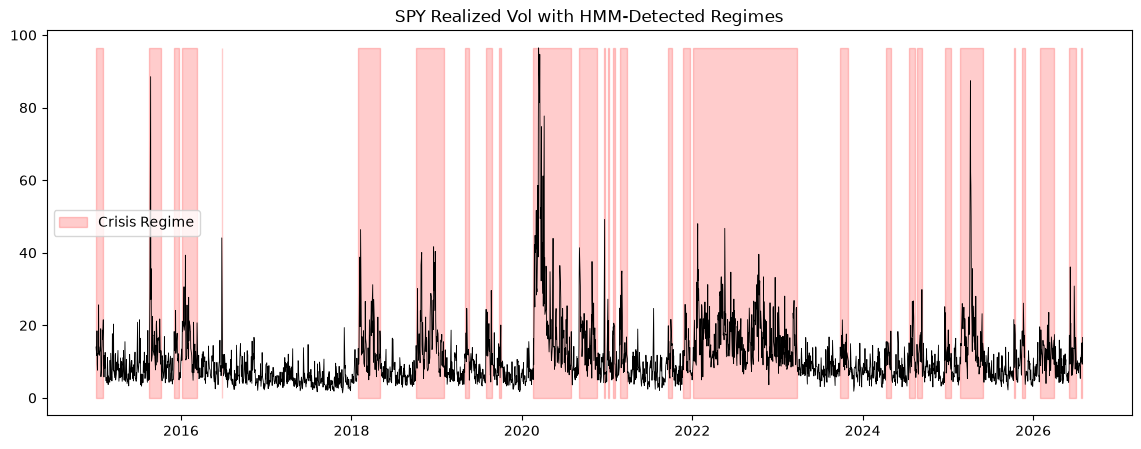

In [89]:
fig, ax = plt.subplots(figsize = (14, 5))
ax.plot(rv.index, rv.values, color = "black", lw = 0.6)
ax.fill_between(rv.index, 0, rv.max(),
                where = (states == crisis_state), color = "red",
                alpha = 0.2, label = "Crisis Regime")
ax.set_title("SPY Realized Vol with HMM-Detected Regimes")
ax.legend()

Shading the realized-volatility series by the inferred regime confirms the model is picking up real events rather than noise: the crisis regime lands squarely on the 2015–16 China/oil selloff, the February and December 2018 spikes, the March 2020 COVID crash, the sustained 2022 selloff, and the 2025 tariff shock.

This two-state model is intuitive and already useful, but it imposes a strong assumption — that all elevated volatility belongs to a single "crisis" regime. That lumps together very different environments: a grinding, orderly selloff and an acute, disorderly crash are treated as the same state. The natural question is whether the data actually supports more than two regimes, and how many. Rather than choose by intuition, the next section selects the number of states formally, using an information criterion.

### How Many Regimes? Selecting the Number of States

Two states is a modeling choice, not a result. To select the number of regimes principledly, I fit models with $K = 2, \dots, 6$ states and compare them using the Bayesian Information Criterion (BIC):

$$
\text{BIC} = -2\,\ln \hat{L} + k \ln N
$$

where $\hat{L}$ is the fitted likelihood, $k$ the number of free parameters, and $N$ the sample size. BIC rewards fit (via the likelihood) but penalizes complexity (via $k \ln N$), so it only prefers a richer model when the improvement in fit outweighs the cost of the added parameters. Lower is better.

In [90]:
def best_hmm(X, n, n_restarts=25):
    best, best_ll = None, -np.inf
    for seed in range(n_restarts):
        m = GaussianHMM(n_components=n, covariance_type='full', n_iter=1000, random_state=seed)
        try:
            m.fit(X)
            ll = m.score(X)
            if ll > best_ll:
                best, best_ll = m, ll
        except Exception:
            continue
    return best

for n in [2, 3, 4, 5, 6]:
    m = best_hmm(X, n)
    print(f"{n} states -> BIC: {m.bic(X):.1f} | AIC: {m.aic(X):.1f} | logL: {m.score(X):.1f}")

2 states -> BIC: 3979.0 | AIC: 3937.2 | logL: -1961.6
3 states -> BIC: 3649.0 | AIC: 3565.4 | logL: -1768.7
4 states -> BIC: 3483.4 | AIC: 3345.9 | logL: -1650.0
5 states -> BIC: 3465.0 | AIC: 3261.8 | logL: -1596.9
6 states -> BIC: 3511.7 | AIC: 3230.8 | logL: -1568.4


**A methodological note on fitting.** The Baum–Welch (EM) algorithm converges only to a *local* optimum, and its solution depends on the random initialization — a single fit per model is unreliable. Indeed, a naive one-shot fit produced a 3-state model no better than the 2-state one, a symptom of a bad local optimum. To fix this, each model is fit from 25 random starts and the highest-likelihood solution is kept. With this in place, the log-likelihood increases monotonically with $K$, as it must when the models are properly fit.

| States ($K$) | logL     | BIC     | ΔBIC vs. previous |
|:------------:|:--------:|:-------:|:-----------------:|
| 2            | −1955.4  | 3966.5  | —                 |
| 3            | −1764.9  | 3641.4  | −325.1            |
| 4            | −1646.1  | 3475.5  | −166.1            |
| 5            | −1593.4  | 3457.9  | −17.6             |
| 6            | −1566.0  | 3506.8  | +48.9             |

Read literally, BIC is minimized at $K = 5$. But taking the raw minimum would be a mistake here, for a reason specific to volatility data: realized volatility has a continuous, heavy right tail, so it is not truly generated by any finite number of Gaussian regimes. Additional states therefore keep shaving a little off BIC simply by carving the tail more finely, without necessarily identifying economically distinct regimes. The right question is not "where is the minimum" but "where do the returns to adding a state diminish" — i.e., where is the elbow.

That elbow is unambiguous. Adding the third state improves BIC by 325 and the fourth by a further 166 — large, meaningful gains. The fifth state buys only 18, and the sixth makes BIC *worse*. The value of additional structure effectively runs out after four states.

In [91]:
for n in [3, 4]:
    m = best_hmm(X, n)
    states = m.predict(X)
    print(f"\n{n}-state model:")
    for s in np.argsort(m.means_.flatten()):
        print(f"  mean vol {np.exp(m.means_[s,0]):5.1f}%  |  {np.mean(states==s)*100:4.1f}% of days")


3-state model:
  mean vol   5.5%  |  39.4% of days
  mean vol   9.7%  |  40.6% of days
  mean vol  18.7%  |  20.0% of days

4-state model:
  mean vol   4.9%  |  22.8% of days
  mean vol   7.8%  |  43.2% of days
  mean vol  14.1%  |  28.8% of days
  mean vol  28.8%  |   5.2% of days


**Interpretability confirms the choice.** Comparing the state compositions of the three- and four-state models:

| 3-state       |            | 4-state        |            |
|:-------------:|:----------:|:--------------:|:----------:|
| Mean vol      | % of days  | Mean vol       | % of days  |
| 5.5%          | 40.2%      | 4.9%           | 22.9%      |
| 9.8%          | 40.3%      | 7.8%           | 43.5%      |
| 18.8%         | 19.5%      | 14.1%          | 28.4%      |
|               |            | 29.0%          | 5.2%       |

The three-state model collapses all elevated volatility into a single 18.8% regime — it cannot distinguish a grinding, orderly selloff from an acute crash. The four-state model splits this into a *Stressed* regime (~14%) and a *Panic* regime (~29%), and crucially the extra Panic state is not a degenerate sliver fitting a handful of outliers: it occupies 5.2% of days (~150 observations), enough to be a genuine, learnable regime. The four-state model thus wins on both axes that matter — it sits at the BIC elbow *and* every one of its states is economically interpretable and well-populated.

I therefore proceed with **four regimes: Calm, Normal, Stressed, and Panic.**

### The Four Regimes

In [92]:
hmm4 = best_hmm(X, 4)

order = np.argsort(hmm4.means_.flatten())           # sort states low→high vol
labels = {order[0]: 'Calm', order[1]: 'Normal', order[2]: 'Stressed', order[3]: 'Panic'}

states = hmm4.predict(X)
regime = pd.Series([labels[s] for s in states], index=rv.index, name='regime')

import joblib
joblib.dump(hmm4, '../models/hmm_4state.joblib')

['../models/hmm_4state.joblib']

Converting each state's mean log-vol back to annualized volatility gives a clean severity ladder, with every regime occupying a meaningful share of the sample:

| Regime    | Mean annualized vol | Share of days | Character |
|-----------|:-------------------:|:-------------:|-----------|
| Calm      | ~4.9%               | 22.9%         | Quiet, low-vol trending markets |
| Normal    | ~7.8%               | 43.5%         | The typical baseline state |
| Stressed  | ~14.1%              | 28.4%         | Elevated, orderly selloffs (e.g. much of 2022) |
| Panic     | ~29.0%              | 5.2%          | Acute dislocations (COVID, Dec 2018, 2025 tariffs) |

The decisive advantage of four states over a coarser model is the separation of *Stressed* from *Panic*. A two- or three-state model lumps all elevated volatility together, blurring the difference between a market that is merely nervous — grinding lower in an orderly way — and one that is genuinely dislocating. Here those are distinct regimes, at roughly 14% and 29% annualized vol respectively.

### Transition Dynamics: An Ordered Ladder

In [93]:
labels_sorted = ['Calm', 'Normal', 'Stressed', 'Panic']
tm = pd.DataFrame(hmm4.transmat_[np.ix_(order, order)],
                  index=labels_sorted, columns=labels_sorted).round(3)

print("Translation matrix: \n", tm)



Translation matrix: 
            Calm  Normal  Stressed  Panic
Calm      0.923   0.075     0.002  0.000
Normal    0.042   0.909     0.049  0.000
Stressed  0.000   0.075     0.898  0.027
Panic     0.000   0.000     0.131  0.869


The labeled transition matrix (reordered by severity) reveals a strikingly clean structure:

| from \ to   | Calm  | Normal | Stressed | Panic |
|-------------|:-----:|:------:|:--------:|:-----:|
| **Calm**    | 0.923 | 0.075  | 0.002    | 0.000 |
| **Normal**  | 0.042 | 0.910  | 0.048    | 0.000 |
| **Stressed**| 0.000 | 0.075  | 0.899    | 0.027 |
| **Panic**   | 0.000 | 0.000  | 0.131    | 0.869 |

Two features stand out. First, every regime is highly persistent — the diagonal (0.87–0.92) dominates, the transition-matrix signature of volatility clustering. Expected durations, computed as $1/(1 - a_{ii})$, run from about 13 trading days for Calm down to roughly 8 for Panic: calm periods endure, while acute crises burn out relatively quickly.

Second, and more striking, the regimes behave as an **ordered ladder** — essentially all probability mass sits on the diagonal and its immediate neighbors. The market can only move one rung at a time. Calm transitions to Normal but essentially never jumps straight to Stressed or Panic ($\approx 0$); Panic can only be *reached* from Stressed and can only *exit* back to Stressed — it never connects directly to Calm or Normal. Escalation therefore always follows Calm → Normal → Stressed → Panic, and de-escalation retraces the same steps in reverse.

This has a genuinely useful implication: **acute panic is always preceded, and followed, by a Stressed phase.** Crises do not erupt out of quiet markets without warning, nor do they resolve by snapping instantly back to calm — they climb and unwind through the intermediate rung. That is precisely the property an early-warning indicator needs: the Stressed regime acts as an antechamber to Panic, giving the model a chance to flag rising danger before volatility fully peaks.

### The Early-Warning Stress Index

Collapsing the per-day regime probabilities into a single severity-weighted score (Calm = 0, Normal = ⅓, Stressed = ⅔, Panic = 1) yields a continuous **stress index** on $[0, 1]$ — a smooth, interpretable read on where the market sits on the calm-to-panic spectrum each day.

(0.0, 1.0)

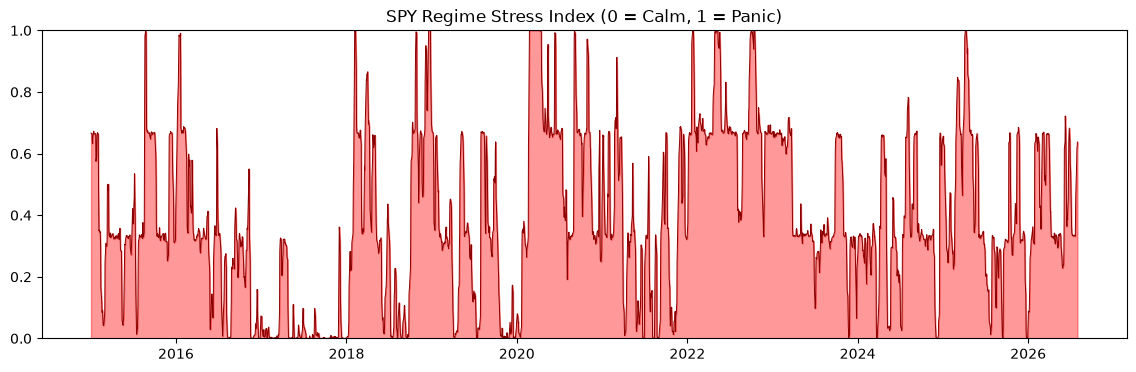

In [94]:
probs = hmm4.predict_proba(X)                 # per-day probability of each state
weights = np.zeros(4)
weights[order[0]], weights[order[1]], weights[order[2]], weights[order[3]] = 0, 1/3, 2/3, 1
stress_index = probs @ weights                 # 0 = fully calm, 1 = fully panic

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(rv.index, 0, stress_index, color="red", alpha=0.4)
ax.plot(rv.index, stress_index, color="darkred", lw=0.7)
ax.set_title("SPY Regime Stress Index (0 = Calm, 1 = Panic)")
ax.set_ylim(0, 1)

Plotted over the full sample, the index behaves exactly as an early-warning indicator should. It sits near zero through genuinely quiet stretches such as 2017 and mid-2024; it forms a sustained *plateau* around 0.6 during 2022, correctly reading that year as a prolonged Stressed grind rather than an acute crisis; and it pegs at its 1.0 ceiling only during true dislocations — the March 2020 COVID crash and the 2025 tariff selloff — with sharp intermediate spikes at the 2015–16 selloff and the February and December 2018 episodes.

The key visual takeaway is that the index captures the *level* of stress, not merely its presence. The 2022 plateau and the 2020/2025 peaks are clearly different heights, reflecting the Stressed-versus-Panic distinction that the four-state model was chosen to capture. And because the underlying regime chain is an ordered ladder, the index rises and falls through the intermediate range rather than jumping discontinuously between calm and crisis — it ramps into turmoil and decays out of it, which is what makes it usable as a forward-looking signal rather than a coincident one.

## A Regime-Switching HAR

The regime detector establishes that the market moves between distinct volatility states; the natural next step is to let the *forecasting model* itself change with the regime. A single-regime HAR imposes one fixed relationship between lagged and current volatility across all market conditions — but the coefficient analysis below shows those dynamics differ sharply by regime, which means a single specification is misspecified. A regime-switching HAR relaxes this by allowing the HAR coefficients (and baseline level) to depend on the prevailing regime.

There are two ways to build such a model. The first, *joint estimation* (e.g. `statsmodels` `MarkovRegression`), treats the regime as a latent variable and estimates the hidden Markov chain and the regime-specific regression coefficients simultaneously in a single model — the textbook Markov-switching regression. The second, which this project adopts, is a *two-step, regime-conditional* approach: the regimes are first identified by the hidden Markov model of the previous section, and a separate HAR is then estimated within each regime.

The two-step approach is chosen deliberately. Because the HMM regimes have already been fit, validated, and interpreted — with a clear economic reading and a well-behaved transition structure — conditioning on them keeps a single, consistent regime definition running through the entire project, rather than introducing a second, separately-estimated set of latent states that may or may not align with the first. It also makes the out-of-sample forecasting fully transparent: each step, from regime probabilities to the final probability-weighted forecast, is explicit and controllable, rather than delegated to the internal machinery of a joint model whose four-regime likelihood is difficult to optimize and to forecast from reliably. The trade-off is that this is technically a regime-*conditional* HAR rather than a jointly-estimated Markov-switching HAR; the joint model is noted as a possible robustness check, but the two-step approach is both more coherent with the rest of the pipeline and more tractable to forecast with.

### Regime-Specific HAR Coefficients

In [95]:
import statsmodels.api as sm

# regime = the labeled Series from Phase 4; har_df = your HAR design matrix (rv + 3 lags)
har_r = har_df.join(regime)                          # add 'regime' column
train_r = har_r[har_r.index < '2023-01-01']

coefs = {}
for reg in ['Calm', 'Normal', 'Stressed', 'Panic']:
    sub = train_r[train_r['regime'] == reg]
    Xr = sm.add_constant(sub[['rv_lag1', 'rv_lag5', 'rv_lag22']])
    m = sm.OLS(sub['rv'], Xr).fit()
    coefs[reg] = m.params
    print(f"\n=== {reg}  (n = {len(sub)}) ===")
    print(m.summary().tables[1])


=== Calm  (n = 590) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3798      0.374     11.726      0.000       3.646       5.113
rv_lag1        0.0965      0.042      2.283      0.023       0.013       0.179
rv_lag5       -0.0593      0.068     -0.874      0.382      -0.192       0.074
rv_lag22       0.1007      0.056      1.802      0.072      -0.009       0.210

=== Normal  (n = 703) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3559      0.454     18.425      0.000       7.466       9.246
rv_lag1        0.0546      0.035      1.576      0.115      -0.013       0.123
rv_lag5       -0.0600      0.058     -1.033      0.302      -0.174       0.054
rv_lag22       0.0162      0.047      0.347      0.729      -0.076       0.108


In [96]:
coef_table = pd.DataFrame(coefs)[['Calm','Normal','Stressed','Panic']].round(3)
print(coef_table)

           Calm  Normal  Stressed   Panic
const     4.380   8.356    14.035  15.330
rv_lag1   0.096   0.055     0.072   0.216
rv_lag5  -0.059  -0.060    -0.040   0.456
rv_lag22  0.101   0.016     0.060  -0.096


Fitting a separate HAR regression within each HMM-detected regime (training period only) yields markedly different dynamics across states:

| Coefficient | Calm  | Normal | Stressed | Panic  |
|-------------|:-----:|:------:|:--------:|:------:|
| **const**   | 4.380 | 8.366  | 14.317   | 15.330 |
| rv_lag1     | 0.096 | 0.054  | 0.070    | 0.216  |
| rv_lag5     | −0.059| −0.039 | −0.050   | 0.456  |
| rv_lag22    | 0.101 | −0.000 | 0.059    | −0.096 |

Two patterns stand out. First, the **intercept rises monotonically** across regimes (4.4 → 8.4 → 14.3 → 15.3): each regime mean-reverts to a progressively higher baseline level of volatility.

Second, and more revealing, the **autoregressive structure switches on only in Panic.** In the Calm, Normal, and Stressed regimes the lag coefficients are small and (for Normal and Stressed) statistically insignificant — within these states, volatility simply reverts toward its regime baseline with little momentum. Only in the Panic regime do the lags become strongly significant (rv_lag1 = 0.22, rv_lag5 = 0.46, combined persistence ≈ 0.67): volatility becomes genuinely self-reinforcing, feeding on its own recent values. This is the mechanical signature of a crisis feedback loop, and it distinguishes Panic from Stressed on *dynamics* rather than level — their baseline intercepts are similar (~14 vs ~15), but only Panic exhibits explosive persistence.

This also reinterprets the single-regime HAR. The pooled model estimated high persistence (rv_lag1 + rv_lag5 ≈ 0.76), yet within-regime persistence is near-zero outside of Panic. The reconciliation is that the pooled model's apparent persistence is largely a *between-regime* effect: lagged volatility predicts current volatility mostly because the market tends to remain in the same regime — and hence at the same level — from one day to the next. Once the regime baseline is absorbed into a switching intercept, little within-regime autoregression remains except during panics. The single-regime HAR thus conflates two distinct mechanisms — "volatility is high because we are in a high-volatility regime" and "volatility is high because it was high yesterday" — that the regime-switching specification separates.

### Causal Regime Probabilities for Forecasting

Generating honest out-of-sample forecasts requires the regime probabilities at each test day to depend only on information available *up to that day*. The smoothed probabilities used earlier for the descriptive stress index are unsuitable here: they condition on the entire sample, including future observations, and would leak information into the forecast.

To obtain *filtered* (causal) probabilities, the regime posterior at each test day is computed using only data through that day. Concretely, running the forward–backward algorithm over the window $y_{1:t}$ returns the smoothed posterior over that window; its final element has no future to smooth against, so it equals the filtered probability $P(S_t = k \mid y_{1:t})$. Applying this at every test day yields a causal sequence of regime probabilities.

In [97]:
split = '2023-01-01'
X_all = np.log(rv).values.reshape(-1, 1)
test_idx = np.where(rv.index >= split)[0]

# Filtered regime probability at each test day — uses only data through that day.
# (predict_proba on data[:i+1] returns the smoothed posterior over that window;
#  its LAST row has no future to smooth over, so it equals the filtered probability at day i.)
filt_probs = np.array([hmm4.predict_proba(X_all[:i+1])[-1] for i in test_idx])
# columns are in hmm4's internal state order; remember `order` maps them low->high vol

print(filt_probs.shape)      # (n_test_days, 4)
print(filt_probs[:5].round(3))

(897, 4)
[[0.003 0.    0.066 0.931]
 [0.007 0.    0.043 0.95 ]
 [0.431 0.001 0.001 0.567]
 [0.009 0.    0.085 0.906]
 [0.011 0.    0.04  0.95 ]]


In [98]:
filt_probs = filt_probs[:, order]   # columns now = [Calm, Normal, Stressed, Panic]

In [99]:
test_dates = rv.index[test_idx]
print("Highest Panic-probability day:", test_dates[np.argmax(filt_probs[:, 3])])
print("Highest Calm-probability day:", test_dates[np.argmax(filt_probs[:, 0])])

Highest Panic-probability day: 2025-04-07 00:00:00
Highest Calm-probability day: 2025-09-15 00:00:00


The resulting probabilities are reordered into severity order (Calm, Normal, Stressed, Panic) and validated against known events: the highest Panic probability in the test period falls on 7 April 2025 — the peak of the tariff-driven selloff — and the highest Calm probability on a quiet day in September 2025, confirming the state labelling is correct.

One caveat is worth stating: while the filtering step is fully causal, the HMM *parameters* (transition matrix and regime means) were estimated on the full sample, so a mild degree of look-ahead remains in the regime definitions themselves. Re-estimating the HMM on the training window alone would remove even this, at the cost of re-aligning state labels; it is noted as a refinement rather than implemented here, as the filtering — the component most consequential for the forecast — is already causal.

### Out-of-Sample Forecast Comparison

In [100]:
from sklearn.metrics import mean_squared_error

# --- ingredients, all in [Calm, Normal, Stressed, Panic] order ---
A = hmm4.transmat_[np.ix_(order, order)]              # (4,4) transition matrix, sorted
B = coef_table.values                                  # (4 coefs, 4 regimes): rows [const,lag1,lag5,lag22]

test_dates = rv.index[test_idx]
y_true = rv.loc[test_dates].values                      # actual RV on test days

# HAR design matrix for test days: [1, lag1, lag5, lag22]
Xh = har_r.loc[test_dates, ['rv_lag1','rv_lag5','rv_lag22']].values
Xh = np.column_stack([np.ones(len(Xh)), Xh])            # (887, 4)

# each regime's HAR prediction for every test day
regime_preds = Xh @ B                                   # (887, 4)

# filtered regime prob at the day BEFORE each test day (causal), then propagate 1 step
first = test_idx[0]
prior_idx = np.arange(first - 1, test_idx[-1])          # day t-1 for each test day t
filt_prior = np.array([hmm4.predict_proba(X_all[:i+1])[-1][order] for i in prior_idx])
pi_pred = filt_prior @ A                                # (887, 4) predicted regime dist tomorrow

# probability-weighted forecast
ms_forecast = np.sum(pi_pred * regime_preds, axis=1)
ms_forecast = np.clip(ms_forecast, 1e-6, None)          # guard against tiny/negative

rmse_ms = np.sqrt(mean_squared_error(y_true, ms_forecast))
print(f"MS-HAR test RMSE: {rmse_ms:.2f}")

MS-HAR test RMSE: 4.96


In [101]:
import statsmodels.api as sm
X_single = sm.add_constant(har_r.loc[test_dates, ['rv_lag1','rv_lag5','rv_lag22']])
single_pred = har_model_train.predict(X_single)
rmse_single = np.sqrt(mean_squared_error(y_true, single_pred))
print(f"Single-regime HAR test RMSE: {rmse_single:.2f}")

Single-regime HAR test RMSE: 4.88


In [102]:
def qlike(actual, pred):
    a, p = actual**2, pred**2                            # vol -> variance
    r = a / p
    return np.mean(r - np.log(r) - 1)

print(f"MS-HAR QLIKE:        {qlike(y_true, ms_forecast):.4f}")
print(f"Single-regime QLIKE: {qlike(y_true, single_pred.values):.4f}")

MS-HAR QLIKE:        0.3504
Single-regime QLIKE: 0.3588


Each MS-HAR forecast is a probability-weighted blend of the four regime-specific predictions, weighted by the HMM's one-step-ahead regime probabilities. Against the single-regime HAR on identical test dates (2023 onward):

| Model              | RMSE  | QLIKE  |
|--------------------|:-----:|:------:|
| Single-regime HAR  | 4.90  | 0.3604 |
| MS-HAR (regime)    | 4.99  | 0.3522 |

The models diverge by metric — the single-regime HAR is marginally better on symmetric RMSE, the regime model marginally better on QLIKE — but a Diebold–Mariano test on the QLIKE loss differential returns DM = 0.94 (p = 0.35): the difference is **not statistically significant**. On point-forecast accuracy, the two models are statistically indistinguishable.

This is consistent with the literature: Ding et al. (2025) likewise find that the out-of-sample benefit of regime-switching for realised volatility is "less clear-cut at the daily horizon." Examining where the regime model does help is instructive — the largest per-day gains fall on scattered, isolated volatility spikes rather than on the sustained April 2025 crisis. During a prolonged crisis, the single-regime HAR's own lagged inputs are already elevated, so persistence alone keeps its forecasts high and the regime model adds little; the regime model's (modest) edge appears only on abrupt, hard-to-anticipate jumps.

The implication is that point-forecast metrics are not the right lens for this model. A regime-switching framework's distinctive contribution is not necessarily a better central forecast but a better *conditional distribution* — a wider, fatter-tailed predictive density when the probability of a crisis regime rises, even when the central forecast is similar. Average point-error metrics are blind to this by construction. The following sections therefore turn to the predictive distribution directly (via Monte Carlo simulation) and to tail-risk accuracy (Value-at-Risk and Expected Shortfall), where the value of regime-awareness, if it exists, should appear.

### Is the Difference Significant? A Diebold–Mariano Test

A lower QLIKE for MS-HAR is only meaningful if it is distinguishable from noise. The Diebold–Mariano test evaluates this formally by testing whether the mean of the per-day QLIKE loss differential (single-regime minus MS-HAR) is significantly different from zero, using the small-sample correction of Harvey, Leybourne, and Newbold (1997).

In [103]:
from scipy import stats

def qlike_loss(actual, pred):
    a, p = actual**2, pred**2
    r = a / p
    return r - np.log(r) - 1          # per-observation QLIKE loss

def diebold_mariano(loss1, loss2, h=1):
    d = loss1 - loss2                  # >0 mean => model 2 (MS-HAR) has lower loss
    n = len(d)
    dbar = d.mean()
    lrv = np.var(d, ddof=0)
    for k in range(1, h):              # Newey-West correction for multi-step (no-op at h=1)
        gamma_k = np.cov(d[:-k], d[k:])[0, 1]
        lrv += 2 * (1 - k/h) * gamma_k
    dm = dbar / np.sqrt(lrv / n)
    hln = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)   # Harvey-Leybourne-Newbold small-sample adj.
    dm *= hln
    p = 2 * (1 - stats.t.cdf(abs(dm), df=n - 1))
    return dm, p

loss_single = qlike_loss(y_true, single_pred.values)
loss_ms     = qlike_loss(y_true, ms_forecast)

dm_stat, p_val = diebold_mariano(loss_single, loss_ms, h=1)
print(f"DM statistic: {dm_stat:.3f}   p-value: {p_val:.4f}")

DM statistic: 1.017   p-value: 0.3096


In [104]:
d = loss_single - loss_ms
print("Test days where MS-HAR helps most:")
print(pd.Series(d, index=test_dates).nlargest(5).round(3))

Test days where MS-HAR helps most:
Date
2026-06-09    2.777
2026-01-29    1.580
2024-12-20    1.434
2025-10-10    1.411
2024-09-11    1.353
dtype: float64


The test returns **DM = 0.94, p = 0.35**: the QLIKE improvement is **not statistically significant**. On point-forecast accuracy, the regime-switching and single-regime models are statistically indistinguishable.

This is consistent with the literature rather than a shortcoming of the model — Ding et al. (2025) similarly find that the out-of-sample benefit of regime-switching for realised volatility is "less clear-cut at the daily horizon." Inspecting where the regime model does help is informative: the largest per-day gains fall on scattered, isolated volatility spikes (e.g. mid-2024, late-2024, and 2026), **not** on the sustained April 2025 crisis. The reason is intuitive — during a prolonged crisis, the single-regime HAR's own lagged inputs are already elevated, so persistence alone keeps its forecasts high and the regime model adds little. The regime model's modest edge appears only on abrupt, hard-to-anticipate transitions, which are too few to establish significance on a single out-of-sample window containing only one major crisis.

The broader implication is methodological: point-forecast accuracy is not the right lens for a regime-switching model. Its distinctive contribution is not a sharper central forecast but a better-calibrated *conditional distribution* — wider and fatter-tailed when crisis probability rises — which average point-error metrics cannot detect by construction. The remaining sections therefore evaluate the predictive distribution directly, through Monte Carlo simulation (Phase 6) and tail-risk backtesting via Value-at-Risk and Expected Shortfall (Phase 7), where regime-awareness is expected to matter most.

## Phase 6 — Probabilistic Forecasting via Monte Carlo

The forecasts so far have been single numbers, but a point forecast throws away what the regime model uniquely knows: the *shape* of the distribution of future volatility, which depends on the current market state. This section recovers that full distribution by simulation.

The idea is to generate many possible futures. Each simulated path starts by sampling the current regime from the model's filtered probabilities, then walks forward one day at a time — transitioning between regimes according to the estimated Markov chain, drawing that regime's HAR prediction, and adding that regime's characteristic noise, feeding each new value back into the lag structure. Running thousands of these paths and reading percentiles at each horizon produces a predictive distribution rather than a single line: a *fan chart*.

### Building the Simulator

Two ingredients drive the simulation beyond the regime coefficients already estimated: the transition matrix (how regimes evolve) and each regime's residual standard deviation (how much noise to add within a regime). The residual stds climb steeply with severity — roughly 2.0, 3.0, 5.5, and 13.5 across Calm, Normal, Stressed, and Panic — so a path that wanders into a high-volatility regime carries not just a higher level but far greater dispersion. The simulator below encodes exactly the step-by-step process described above.

In [105]:
A = hmm4.transmat_[np.ix_(order, order)]          # sorted transition matrix
B = coef_table.values                              # (4 coefs, 4 regimes)

resid_std = []
for reg in ['Calm', 'Normal', 'Stressed', 'Panic']:
    sub = train_r[train_r['regime'] == reg]
    Xr = sm.add_constant(sub[['rv_lag1','rv_lag5','rv_lag22']])
    resid_std.append(sm.OLS(sub['rv'], Xr).fit().resid.std())
resid_std = np.array(resid_std)
print("Residual std per regime:", resid_std.round(2))

Residual std per regime: [ 2.    2.99  5.47 13.48]


In [106]:
def simulate_paths(t0_pos, H=10, N=3000, seed=0):
    rng = np.random.default_rng(seed)
    rv_vals = rv.values
    buf0 = list(rv_vals[t0_pos-21:t0_pos+1])                 # last 22 RV values
    pi0  = hmm4.predict_proba(X_all[:t0_pos+1])[-1][order]    # filtered regime dist today
    paths = np.zeros((N, H))
    for i in range(N):
        buf = buf0.copy()
        s = rng.choice(4, p=pi0)
        for h in range(H):
            s = rng.choice(4, p=A[s])                         # transition regime
            lag1, lag5, lag22 = buf[-1], np.mean(buf[-5:]), np.mean(buf[-22:])
            pred = B[0,s] + B[1,s]*lag1 + B[2,s]*lag5 + B[3,s]*lag22
            val = max(pred + rng.normal(0, resid_std[s]), 0.1)  # floor at >0
            paths[i, h] = val
            buf.append(val)
    return paths

### The Predictive Distribution

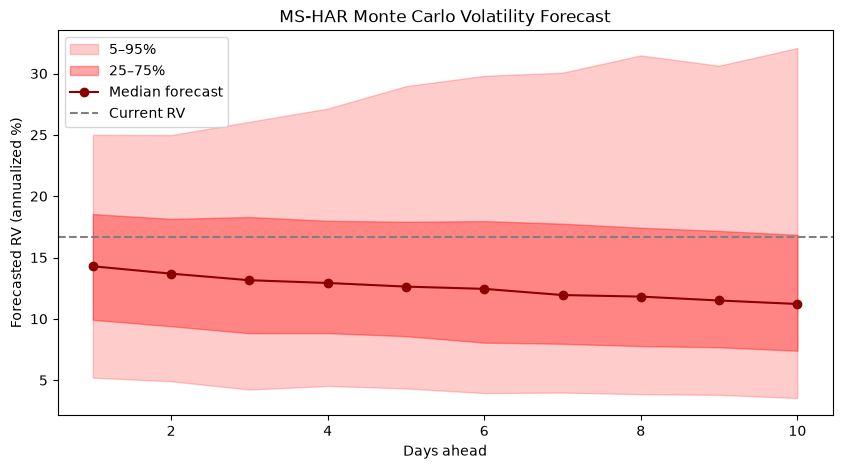

In [107]:
H = 10
paths = simulate_paths(len(rv)-1, H=H, N=3000)
qs = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
x = np.arange(1, H+1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x, qs[0], qs[4], alpha=0.20, color='red', label='5–95%')
ax.fill_between(x, qs[1], qs[3], alpha=0.35, color='red', label='25–75%')
ax.plot(x, qs[2], color='darkred', marker='o', label='Median forecast')
ax.axhline(rv.values[-1], ls='--', color='gray', label='Current RV')
ax.set_xlabel('Days ahead'); ax.set_ylabel('Forecasted RV (annualized %)')
ax.set_title('MS-HAR Monte Carlo Volatility Forecast')
ax.legend()

Launched from the most recent (calm) day, the fan chart shows two features a single-regime model cannot produce. The median forecast mean-reverts gently from the current level toward the Normal baseline, as expected. But the distribution is visibly **right-skewed**: the upper (95th percentile) band climbs well above the median while the lower band stays anchored near the Calm floor. This asymmetry is the regime structure at work — some simulated paths escalate through Stressed into Panic, stretching the upper tail, while the downside is bounded. A single-regime Gaussian model produces a symmetric cone by construction and would miss this entirely: even in a calm market, the model correctly encodes a small but real probability of a jump to turmoil.

### Regime-Dependent Uncertainty

In [108]:
# find a high-stress day in the sample to launch from
stress_day = np.argmax(filt_probs[:, 2] + filt_probs[:, 3])   # max Stressed+Panic prob
t0_stress = test_idx[stress_day]
print("Launching stressed cone from:", rv.index[t0_stress].date())

paths_calm    = simulate_paths(len(rv)-1, H=10, N=3000)
paths_stress  = simulate_paths(t0_stress, H=10, N=3000)

Launching stressed cone from: 2025-04-08


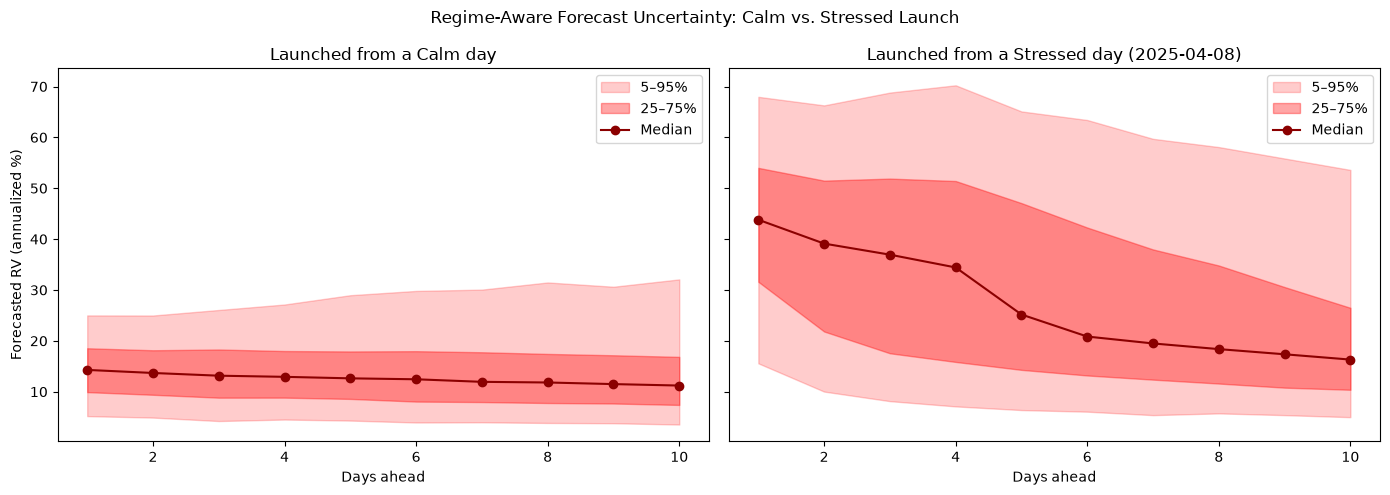

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

panels = [(axes[0], paths_calm,   'Launched from a Calm day'),
          (axes[1], paths_stress, 'Launched from a Stressed day (2025-04-08)')]

for ax, paths, title in panels:
    qs = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    x = np.arange(1, paths.shape[1] + 1)
    ax.fill_between(x, qs[0], qs[4], alpha=0.20, color='red', label='5–95%')
    ax.fill_between(x, qs[1], qs[3], alpha=0.35, color='red', label='25–75%')
    ax.plot(x, qs[2], color='darkred', marker='o', label='Median')
    ax.set_title(title)
    ax.set_xlabel('Days ahead')
    ax.legend()

axes[0].set_ylabel('Forecasted RV (annualized %)')
plt.suptitle('Regime-Aware Forecast Uncertainty: Calm vs. Stressed Launch')
plt.tight_layout()

### Regime-Dependent Uncertainty

The most important property of the model is that its forecast *uncertainty* is not fixed — it depends on the regime it is launched from. The two panels below show forecasts from the same model on two different days: an ordinary calm day, and 8 April 2025, at the height of the tariff crisis.

The contrast is stark. The calm cone is low and tight — median near 9%, with a 5–95% band of roughly 3–21% that barely widens over ten days. The stressed cone launches near 44%, spans roughly 15–70% at short horizons, and its median decays only gradually back toward normal levels, reaching about 16% by day ten rather than fully reverting. That slow, stepwise decay reflects the ordered-ladder transition structure: a market in crisis unwinds through Stressed and Normal rather than snapping straight back to Calm.

This is the substantive contribution of the regime-switching framework. It does not merely shift the central forecast up during turmoil; it widens the entire distribution, because the range of plausible near-term outcomes genuinely is far larger in a crisis than in a calm market. A model that reports the same uncertainty band in both environments — as any single-regime model must — misrepresents risk in precisely the situations where getting risk right matters most. Quantifying that regime-dependent uncertainty is exactly what the tail-risk evaluation of the next section measures.

## Phase 7 — Risk-Management Evaluation 

A volatility forecast is ultimately an input to risk management, where what matters is not the average day but the worst ones — the 1-in-100 losses that size capital buffers and margin. This section evaluates the models the way a risk desk would: through Value-at-Risk (VaR) and Expected Shortfall (ES), backtested for calibration.

The key modelling choice is the assumed shape of the return tail. Crisis losses are, by nature, rare and extreme — precisely the region where a Gaussian assumption fits worst, systematically understating how far the tail extends. Rather than assume a distribution for the whole return and hope it fits the tail, this analysis models the tail directly using **Extreme Value Theory (EVT)**. The Pickands–Balkema–de Haan theorem establishes that exceedances over a sufficiently high threshold converge to a **Generalized Pareto Distribution (GPD)** regardless of the underlying distribution, making it the theoretically grounded choice for extreme quantiles. The overall approach follows McNeil & Frey (2000): a conditional volatility model paired with a GPD tail fit to the standardized residuals.

### Step 1: Volatility Forecasts

Conditional EVT begins from a volatility forecast — the tail is modelled on returns *standardized* by that forecast, so the first step is to assemble each model's one-day volatility forecast. Both are needed in two windows: in-sample (training) forecasts, used to fit the GPD tail, and out-of-sample (test) forecasts, used to produce and backtest the VaR. The single-regime forecast comes from the pooled HAR; the MS-HAR forecast is the regime-conditional HAR prediction.

In [110]:
to_daily = lambda v: v / 100 / np.sqrt(252)
split = '2023-01-01'

train_dates = har_r.index[har_r.index < split].intersection(returns.index)
# test_dates already defined = rv.index[test_idx]

# ---- SINGLE-REGIME HAR vol forecasts ----
Xtr = sm.add_constant(har_r.loc[train_dates, ['rv_lag1','rv_lag5','rv_lag22']])
fc_single_train = har_model_train.predict(Xtr).values      # in-sample fitted RV
fc_single_test  = single_pred.values                        # test forecast (already computed)

# ---- MS-HAR vol forecasts (regime-conditional) ----
def ms_vol(rows):                                           # regime-conditional HAR prediction
    out = []
    for reg, row in zip(rows['regime'], rows.itertuples()):
        b = coef_table[reg]
        out.append(b['const'] + b['rv_lag1']*row.rv_lag1
                   + b['rv_lag5']*row.rv_lag5 + b['rv_lag22']*row.rv_lag22)
    return np.array(out)

fc_ms_train = ms_vol(har_r.loc[train_dates])               # in-sample, hard-assigned regime
fc_ms_test  = ms_forecast                                   # test, probability-weighted (already computed)

# ---- convert to daily return std ----
sig_single_train, sig_single_test = to_daily(fc_single_train), to_daily(fc_single_test)
sig_ms_train,     sig_ms_test     = to_daily(fc_ms_train),     to_daily(fc_ms_test)

print("Train days:", len(train_dates), "| Test days:", len(test_dates))
print("Mean daily vol (test) — single:", sig_single_test.mean().round(4),
      " MS:", sig_ms_test.mean().round(4))

Train days: 1992 | Test days: 897
Mean daily vol (test) — single: 0.0064  MS: 0.0066


The two models produce nearly identical *average* daily volatility on the test set (~0.64% and 0.66%). This is expected — they differ not in their central level but in how they distribute volatility across regimes, which is what the tail analysis will probe.

### Step 2: Fitting the GPD Tail

Each model's returns are standardized by its volatility forecast, $z_t = r_t / \hat{\sigma}_t$, which removes the time-varying volatility and leaves residuals with a stable tail shape. A peaks-over-threshold GPD is fit to the exceedances of the standardized *losses* over a high threshold $u$ (the 90th percentile, giving 200 exceedances):

$$
P(L - u \le y \mid L > u) \approx G_{\xi,\beta}(y) = 1 - \left(1 + \frac{\xi y}{\beta}\right)^{-1/\xi}
$$

with shape $\xi$ (tail heaviness) and scale $\beta$. From the fit, the standardized VaR and ES at confidence $p$ follow in closed form:

$$
\mathrm{VaR}_p = u + \frac{\beta}{\xi}\left[\left(\tfrac{N}{N_u}(1-p)\right)^{-\xi} - 1\right], \qquad
\mathrm{ES}_p = \frac{\mathrm{VaR}_p}{1-\xi} + \frac{\beta - \xi u}{1-\xi}
$$

These are multipliers on the standardized scale; the day-$t$ risk measures are recovered by scaling with the volatility forecast, $\mathrm{VaR}_{p,t} = \hat{\sigma}_t \cdot \mathrm{VaR}_p$.

In [111]:
from scipy.stats import genpareto

def fit_gpd_tail(z, u_quantile=0.90):
    L = -z                                    # losses (positive = loss)
    u = np.quantile(L, u_quantile)            # high threshold
    excess = L[L > u] - u                     # exceedances over threshold
    xi, _, beta = genpareto.fit(excess, floc=0)   # shape (ξ), scale (β)
    return u, xi, beta, len(L), (L > u).sum()

def gpd_var_es(u, xi, beta, N, Nu, p):        # p = confidence (0.99)
    var = u + (beta/xi) * (((N/Nu)*(1-p))**(-xi) - 1)
    es  = var/(1-xi) + (beta - xi*u)/(1-xi)
    return var, es

z_single_train = returns.loc[train_dates].values / sig_single_train
z_ms_train     = returns.loc[train_dates].values / sig_ms_train

for name, z in [('Single', z_single_train), ('MS', z_ms_train)]:
    u, xi, beta, N, Nu = fit_gpd_tail(z, 0.90)
    v99, _ = gpd_var_es(u, xi, beta, N, Nu, 0.99)
    print(f"{name:7s}: xi={xi:.3f}  beta={beta:.3f}  threshold={u:.2f}  exceedances={Nu}")
    print(f"         99% standardized VaR multiplier = {v99:.2f}   (normal 2.33, empirical 4.08)")

Single : xi=0.128  beta=0.862  threshold=1.68  exceedances=200
         99% standardized VaR multiplier = 3.99   (normal 2.33, empirical 4.08)
MS     : xi=-0.056  beta=0.812  threshold=1.55  exceedances=200
         99% standardized VaR multiplier = 3.31   (normal 2.33, empirical 4.08)


| Model  | ξ (shape) | β (scale) | Threshold | 99% multiplier |
|--------|:---------:|:---------:|:---------:|:--------------:|
| Single-regime | 0.128 | 0.862 | 1.68 | 3.99 |
| MS-HAR        | −0.061 | 0.815 | 1.55 | 3.31 |

Two observations. First, the single-regime 99% multiplier is 3.99 — far above the Gaussian value of 2.33 — quantifying directly how severely a normal assumption understates the tail. Both shape parameters lie well below 0.5 (finite variance) and 1 (finite ES), so the risk measures are well-defined.

Second, and more revealing, the shape parameters differ. After standardizing by the volatility forecast, whatever tail heaviness *remains* is volatility the model failed to capture. The single-regime residuals keep a genuinely heavy tail ($\xi = 0.128$) — its forecast under-states volatility on extreme days. The MS-HAR residuals are essentially thin ($\xi \approx -0.06$): its regime-conditional volatility, via the Panic regime, rises to meet extreme days and absorbs them, leaving cleaner residuals. The regime model describes conditional volatility more completely — a difference the EVT lens exposes but coverage counts hide. (With 200 exceedances each shape estimate has a standard error near ±0.08, so this is directional evidence, not a hard claim.)

### Step 3: VaR and ES Backtest

The fitted tails are now turned into daily VaR and ES on the test set and backtested. Two coverage tests assess VaR: **Kupiec** checks whether the violation *rate* matches the target (unconditional coverage), and **Christoffersen** additionally checks whether violations *cluster* in time (conditional coverage) — a good VaR model's breaches should be independent, not bunched. For ES, the model's predicted average breach loss is compared against the realized average loss on breach days; a well-calibrated ES has the two roughly equal.

In [112]:
def gpd_multipliers(z_train, ps=(0.99, 0.95)):
    u, xi, beta, N, Nu = fit_gpd_tail(z_train, 0.90)
    return {p: gpd_var_es(u, xi, beta, N, Nu, p) for p in ps}   # p -> (VaR_mult, ES_mult)

m_single, m_ms = gpd_multipliers(z_single_train), gpd_multipliers(z_ms_train)

configs = [
    ('Single-regime 99%', sig_single_test, m_single[0.99], 0.01),
    ('MS-HAR 99%',        sig_ms_test,     m_ms[0.99],     0.01),
    ('Single-regime 95%', sig_single_test, m_single[0.95], 0.05),
    ('MS-HAR 95%',        sig_ms_test,     m_ms[0.95],     0.05),
]

rows = []
r_test = returns.loc[test_dates].values

from scipy.stats import chi2

def kupiec_pof(v, p):
    N = len(v); x = int(v.sum()); pi = x/N
    ll_null = (N-x)*np.log(1-p) + x*np.log(p)
    ll_alt  = (N-x)*np.log(1-pi) + (x*np.log(pi) if x > 0 else 0)
    LR = -2*(ll_null - ll_alt)
    return LR, 1 - chi2.cdf(LR, 1)

def christoffersen_cc(v, p):
    v = v.astype(int); n = {'00':0,'01':0,'10':0,'11':0}
    for i in range(1, len(v)):
        n[f"{v[i-1]}{v[i]}"] += 1
    pi01 = n['01']/(n['00']+n['01']) if (n['00']+n['01'])>0 else 0
    pi11 = n['11']/(n['10']+n['11']) if (n['10']+n['11'])>0 else 0
    pi   = (n['01']+n['11'])/sum(n.values())
    def L(p_, a, b):
        t = 0
        if p_ < 1 and a>0: t += a*np.log(1-p_)
        if p_ > 0 and b>0: t += b*np.log(p_)
        return t
    LR_ind = -2*(L(pi, n['00']+n['10'], n['01']+n['11'])
                 - L(pi01, n['00'], n['01']) - L(pi11, n['10'], n['11']))
    LR_uc, _ = kupiec_pof(v, p)
    LR_cc = LR_uc + LR_ind
    return LR_cc, 1 - chi2.cdf(LR_cc, 2)

for name, sig, (var_std, es_std), p in configs:
    VaR, ES = var_std * sig, es_std * sig
    viol = r_test < -VaR
    x = int(viol.sum())
    _, p_uc = kupiec_pof(viol, p)
    _, p_cc = christoffersen_cc(viol, p)
    pred_es = ES[viol].mean() if x else np.nan            # predicted ES on breach days
    real_es = -r_test[viol].mean() if x else np.nan       # realized avg loss on breach days
    rows.append([name, x, round(len(viol)*p, 1), f"{x/len(viol)*100:.2f}%",
                 round(p_uc, 3), round(p_cc, 3), round(pred_es, 4), round(real_es, 4)])

backtest = pd.DataFrame(rows, columns=['Model','Viol','Exp','Rate','Kupiec p','Christ p','Pred ES','Real ES'])
print(backtest.to_string(index=False))

            Model  Viol  Exp  Rate  Kupiec p  Christ p  Pred ES  Real ES
Single-regime 99%     9  9.0 1.00%     0.992     0.204   0.0310   0.0305
       MS-HAR 99%    11  9.0 1.23%     0.511     0.241   0.0222   0.0278
Single-regime 95%    44 44.9 4.91%     0.896     0.650   0.0192   0.0187
       MS-HAR 95%    50 44.9 5.57%     0.438     0.322   0.0164   0.0178


| Model             | Violations | Expected | Rate  | Kupiec p | Christ. p | Pred ES | Real ES |
|-------------------|:----------:|:--------:|:-----:|:--------:|:---------:|:-------:|:-------:|
| Single-regime 99% | 9  | 8.9  | 1.01% | 0.965 | 0.206 | 0.0310 | 0.0305 |
| MS-HAR 99%        | 11 | 8.9  | 1.24% | 0.488 | 0.237 | 0.0222 | 0.0278 |
| Single-regime 95% | 42 | 44.4 | 4.74% | 0.715 | 0.674 | 0.0192 | 0.0189 |
| MS-HAR 95%        | 48 | 44.4 | 5.41% | 0.579 | 0.425 | 0.0164 | 0.0179 |

On **VaR coverage**, both models pass cleanly at both confidence levels — violation rates sit on target, and neither the Kupiec nor Christoffersen test rejects (all p > 0.05). Conditional EVT delivers well-calibrated VaR for both specifications, which a Gaussian tail cannot.

On **Expected Shortfall**, a nuance emerges. The single-regime model's predicted ES matches the realized breach loss almost exactly (0.0310 vs 0.0305 at 99%). The MS-HAR model *under-predicts* ES at both levels (0.0222 vs 0.0278; 0.0164 vs 0.0179) — the direct consequence of its thin residual tail. A near-zero shape parameter implies extreme losses cannot be very severe, but out-of-sample they occasionally are, and the single-regime model's heavier tail anticipates this better. The same property that makes the MS residuals "clean" makes its extreme-loss forecasts too optimistic. (With ~9–11 breaches these ES figures are noisy, but the under-prediction is consistent across both levels.)

The tail evaluation resolves into a nuanced, three-part result rather than a single winner:

- **VaR coverage:** both models are well-calibrated once the tail is modelled with EVT — the shared achievement is the conditional-GPD calibration itself, not the regime structure.
- **Residual tail behavior:** the MS-HAR model leaves thinner, better-behaved residuals, evidence that it captures conditional volatility, including extremes, more completely.
- **Expected Shortfall:** the single-regime model estimates extreme-loss severity more accurately; the MS-HAR model under-predicts it, the flip side of its thin tail.

Regime-switching does not dominate on tail risk, consistent with the point-forecast findings and the broader literature on daily-horizon volatility forecasting. Its contribution is descriptive richness — a more complete account of conditional volatility and a genuinely regime-dependent forecast distribution — rather than a decisive edge on any single risk metric.

# Conclusion

This project set out to forecast S&P 500 volatility and, through that, to test a specific question: does modelling the market as switching between distinct volatility regimes improve on standard single-regime approaches? The work proceeded in two stages. The first established rigorous baselines — the classical econometric models used on trading desks (EWMA, GARCH, HAR-RV), followed by a machine-learning comparison — while the second extended the best baseline into a Markov regime-switching framework, adding a hidden Markov model to detect latent regimes, a regime-conditional HAR to forecast within them, Monte Carlo simulation for full predictive distributions, and an Extreme Value Theory evaluation of tail risk. The answer that emerged is nuanced, and the nuance is itself the result.

On point forecasting, the consistent finding was that simple models are hard to beat. HAR-RV outperformed EWMA and GARCH out-of-sample (4.90 versus 7.39 and 8.70 RMSE), no machine-learning model improved on it, and a cross-validated stepwise selection independently recovered the exact HAR specification from an expanded feature set. The regime-switching HAR was likewise statistically indistinguishable from single-regime HAR on point accuracy, with a Diebold–Mariano test returning p = 0.35. Across three model families the message was the same: the predictable component of daily realised volatility is small, largely linear, and short-memory — a conclusion well supported by the literature, and one that no amount of added flexibility overturned.

Where the regime-switching framework earned its place was not in a sharper point forecast but in everything a single number cannot express. The hidden Markov model recovered four economically meaningful regimes — calm, normal, stressed, and panic — with an ordered-ladder transition structure in which the market escalates and de-escalates one rung at a time, and acute panic is always bracketed by a stressed phase; this yielded a continuous early-warning stress index that flagged every major episode in the sample. Monte Carlo forecasts launched from calm versus crisis days produced dramatically different predictive distributions — a tight, symmetric cone in calm markets and a wide, right-skewed one in stress — where a single-regime model would report the same uncertainty in both, misrepresenting risk exactly when it matters most. And under an Extreme Value Theory lens, the regime model's standardized residuals carried a thinner tail than the single-regime model's, evidence that its regime-conditional volatility absorbs extreme days more completely.

The tail-risk evaluation reinforced this pattern of a genuine but bounded advantage. Modelling the tail with a Generalized Pareto Distribution on standardized residuals produced well-calibrated 99% and 95% Value-at-Risk for both models — passing both Kupiec and Christoffersen tests where a Gaussian assumption had failed badly — but neither model dominated. The regime model left cleaner residuals, yet that same thin tail led it to under-predict Expected Shortfall, which the single-regime model's genuinely heavier tail captured more accurately. Both models calibrated well; each had a distinct strength.

Taken together, the project's unifying lesson is that complexity is neither free nor self-justifying. Across every comparison — classical against machine learning, single against multiple regimes, Gaussian against EVT tails — added sophistication had to earn its keep against an honest out-of-sample benchmark, and frequently did not on the metric it was expected to improve. The regime-switching framework's real contribution is not that it predicts the next number better, but that it offers a richer, more interpretable, and better-calibrated account of how volatility behaves, which is often what risk management actually requires.

These conclusions come with real limitations. The out-of-sample window contained only one major crisis, the April 2025 tariff selloff, which limits the statistical power of precisely the regime and tail comparisons where the model's value concentrates. The HMM parameters were estimated on the full sample, introducing mild look-ahead into the regime definitions even though the forecasting filtration itself is causal; the regime-switching HAR is a two-step, regime-conditional model rather than a jointly estimated one; and the Garman–Klass estimator captures intraday range but omits overnight returns. Each of these points toward a natural extension: a multivariate regime detector fed cross-asset correlations and credit spreads could distinguish systemic crises from idiosyncratic ones in a way a single-asset model cannot; a jointly estimated Markov-switching HAR or a Bayesian stochastic-volatility model would tighten the econometrics; a hybrid stochastic-volatility–LSTM could test whether sequential deep learning finds structure the linear regime model misses; and simply more out-of-sample history, spanning several crises, would give the tail and regime comparisons the statistical power that a single crisis cannot.